# Rayleigh-Bénard convection of a Darcy fluid in a porous rectangle

$$
\mathbb{S}
\begin{cases}
\Omega = [0, \mathcal{A}Xl] \times [0, Xl] & \text{aspect ratio } \mathcal{A}=\mathcal{O}(1)\\
\textbf{e}_g=-\textbf{e}_y & \text{gravity acting downwards}\\ 
\phi = 1 & \text{constant porosity} \\
\mathsf{D} = \mathsf{I} & \text{isotropic dispersion}\\ 
\mathsf{K} = \mathsf{I} & \text{isotropic permeability}\\ 
\mu = 1 & \text{constant viscosity} \\
\rho(c) = -c \\
c_0(x,y)=1-y+\mathcal{N}(x,y) & \text{diffusive base state plus noise} \\
c_{\text{D}}(x,y=0)=1 & \text{prescribed temperature on upper and lower boundaries} \\
c_{\text{D}}(x,y=1)=0 \\
c_{\text{N}}(x=0,y)=0 & \text{no-flux on left and right boundaries}\\
c_{\text{N}}(x=L_x,y)=0 \\
\psi_{\text{D}}\vert_{\partial\Omega}=0 & \text{no-penetration on entire boundary}
\end{cases}
$$

In [1]:
from lucifex.fdm import AB2, CN
from lucifex.sim import run
from lucifex.utils import grid, spacetime_grid, as_indices
from lucifex.viz import plot_colormap, plot_line, create_animation, save_figure, display_animation
from py.A04_darcy_convection_rayleigh_benard import darcy_convection_rayleigh_benard_rectangle

simulation = darcy_convection_rayleigh_benard_rectangle(
    aspect=2.0,
    Nx=64,
    Ny=64,
    cell='quadrilateral', 
    scaling='advective',
    Ra=500.0, 
    c_eps=1e-3, 
    c_freq=(12, 8), 
    c_seed=(123, 456), 
    D_adv=AB2,
    D_diff=CN,
    secondary=True,
)

n_stop = 200
dt_init = 1e-6
n_init = 5
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c = simulation['c']

In [ ]:
time_slice = slice(0, None, 2)
titles = [f'$c(t={t:.3f})$' for t in c.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[time_slice], title=titles)
anim_path = save_figure(f'{c.name}(t)', get_path=True)(anim)

display_animation(anim_path)

: 

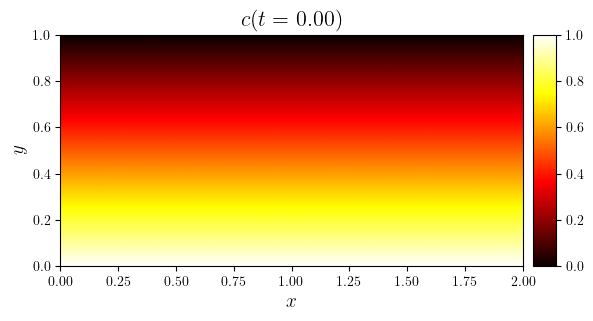

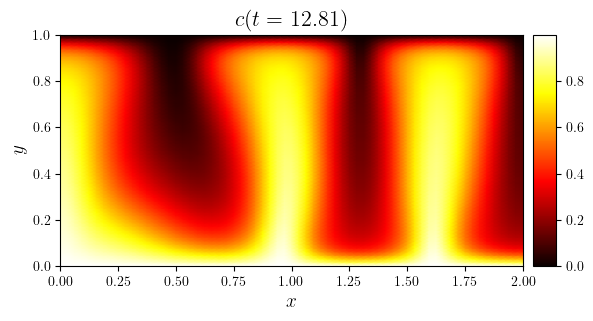

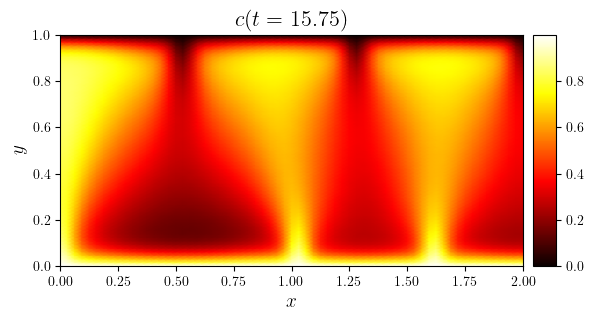

In [4]:
time_indices = as_indices(c.series, (0, 0.5, -1), fraction=True)
for i in time_indices:
    fig, ax = plot_colormap(c.series[i], title=f'$c(t={c.time_series[i]:.2f})$')
    save_figure(f'c(t={c.time_series[i]:.2f})')(fig)

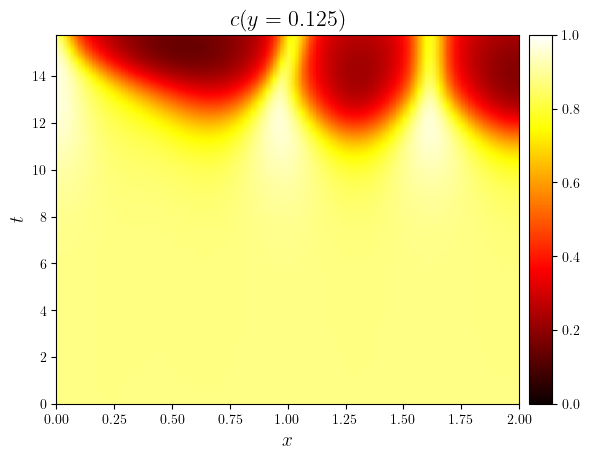

In [4]:
x, y = grid(c.mesh)

y_index = 8
y_value = y[y_index]
c_spacetime = spacetime_grid(c.series, 'y', y_value)

title = f'$c(y={y_value:.3f})$'
fig, ax = plot_colormap(
    (x, c.time_series, c_spacetime), 
    aspect='auto',
    x_label='$x$',
    y_label='$t$',
    title=title,
    colorbar=(0, 1),
)
save_figure(title.strip('$'))(fig)

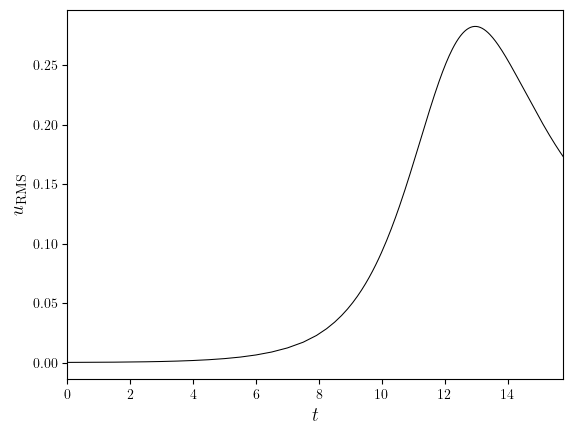

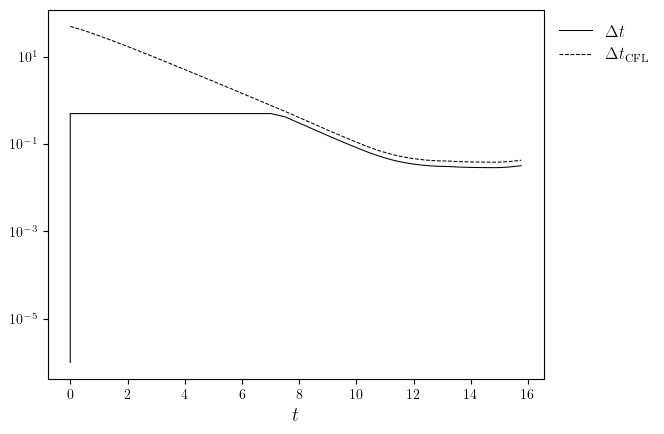

: 

In [ ]:
uRMS, dtCFL, dt = simulation['uRMS', 'dtCFL', 'dt']

fig, ax = plot_line(
    (uRMS.time_series, uRMS.value_series),
    x_label='$t$',
    y_label='$u_{\mathrm{RMS}}$',
)
save_figure('uRMS')(fig)
fig, ax = plot_line(
    [(dt.time_series, dt.value_series), (dtCFL.time_series, dtCFL.value_series)],
    x_label='$t$',
    legend_labels=['$\Delta t$', '$\Delta t_{\mathrm{CFL}}$'],
)
ax.set_yscale('log')
save_figure('dt')(fig)